<a href="https://colab.research.google.com/github/HinaH1/dental-caries-detection-segmentation/blob/main/phase_one/experiment_two_YOLOv8_seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment Two: YOLOv8-seg Instance Segmentation

## Overview
This notebook documents the second experiment of Phase One.
Following on from Experiment One, which showed that bounding box detection was not sufficient for accurately localising carious lesions, this experiment trained a YOLOv8 instance segmentation model on the tumverilerdeneme dataset.

The dataset had been reviewed and approved by a dental professional as
clinically suitable for this task. Instance segmentation was used to produce
pixel-level masks that trace the exact boundary of each lesion rather than
just drawing a rectangle around it.

## Dataset
The tumverilerdeneme dataset was downloaded from Roboflow. Before training,
the Restoration class was removed to keep only caries annotations. The
dataset uses polygon-based segmentation annotations in YOLO format.

## Training Configuration
Two training runs were carried out. The first established a baseline and
the second used a larger image size and early stopping to try to improve
performance and reduce overfitting.

| Parameter | Initial Run | Improved Run |
|---|---|---|
| Model | YOLOv8s-seg | YOLOv8s-seg |
| Epochs | 50 | 100 |
| Image size | 640 | 768 |
| Batch size | 4 | 4 |
| Early stopping | No | Yes, patience 20 |

## Environment Setup and Dataset Download
The following cell installs the required libraries and downloads the
tumverilerdeneme dataset from Roboflow.
Replace the placeholder API key with your own Roboflow credentials before running.

In [ ]:
!pip install roboflow

from roboflow import Roboflow
from google.colab import userdata
api_key = userdata.get("ROBOFLOW")
rf = Roboflow(api_key=api_key)

project = rf.workspace("hinas-workspace").project("tumverilerdeneme-ap2eh")
version = project.version(3)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'yolov8s-seg.pt', 'runs', 'yolo26n.pt', 'data_fixed.yaml', 'drive', 'tümverilerdeneme-3', 'sample_data']


In [ ]:
!ls /content/tümverilerdeneme-3

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


## Data Configuration
The dataset paths in the data.yaml file are updated to match the Colab directory structure before training begins.

In [ ]:
import yaml

yaml_path = "/content/tümverilerdeneme-3/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

# Fix paths
data["train"] = "/content/tümverilerdeneme-3/train/images"
data["val"] = "/content/tümverilerdeneme-3/valid/images"
data["test"] = "tümverilerdeneme-3/test/images"

# Save new YAML
with open("/content/data_fixed.yaml", "w") as f:
    yaml.dump(data, f)

print(data)

{'names': ['caries'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'tumverilerdeneme-ap2eh', 'url': 'https://universe.roboflow.com/hinas-workspace/tumverilerdeneme-ap2eh/dataset/3', 'version': 3, 'workspace': 'hinas-workspace'}, 'test': 'tümverilerdeneme-3/test/images', 'train': '/content/tümverilerdeneme-3/train/images', 'val': '/content/tümverilerdeneme-3/valid/images'}


In [ ]:
from pathlib import Path

for split in ["train", "valid", "test"]:
    img_dir = Path(f"/content/tümverilerdeneme-3/{split}/images")
    label_dir = Path(f"/content/tümverilerdeneme-3/{split}/labels")

    print(split)
    print("images:", len(list(img_dir.glob("*"))))
    print("labels:", len(list(label_dir.glob("*.txt"))))
    print("-"*30)


train
images: 757
labels: 757
------------------------------
valid
images: 95
labels: 95
------------------------------
test
images: 94
labels: 94
------------------------------


## Sample Annotation Visualisation
The following cell displays a sample of training images with their segmentation annotations overlaid, for visual inspection of the annotation quality before training begins.

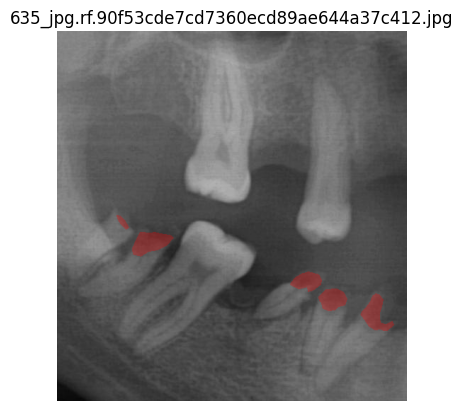

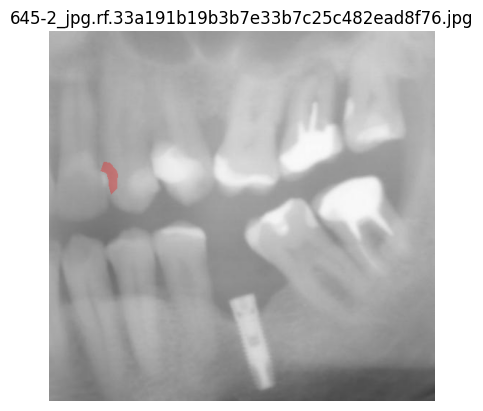

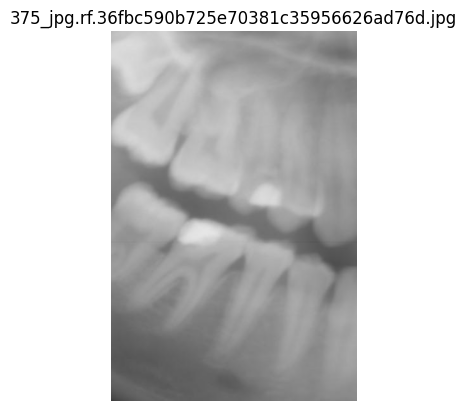

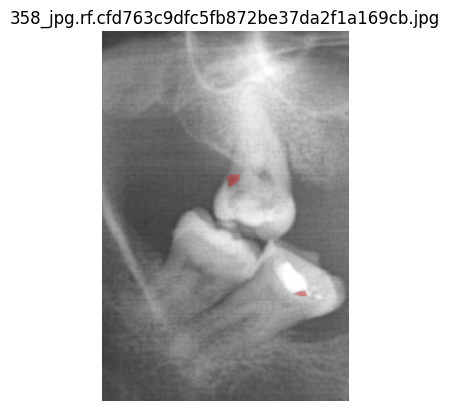

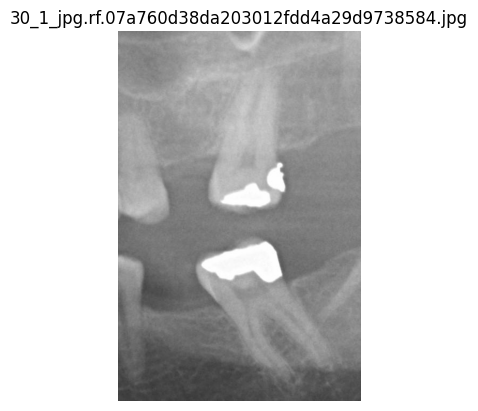

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import numpy as np

yaml_path = "/content/data_fixed.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

names = data["names"]

img_dir = Path(data["train"])
label_dir = Path(str(img_dir).replace("/images", "/labels"))

images = list(img_dir.glob("*.jpg"))

sample = random.sample(images, min(5, len(images)))

for img_path in sample:
    label_path = label_dir / f"{img_path.stem}.txt"

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            cls = int(float(parts[0]))
            coords = list(map(float, parts[1:]))

            pts = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * w)
                y = int(coords[i+1] * h)
                pts.append([x, y])

            pts = np.array(pts, dtype=np.int32)

            cv2.fillPoly(overlay, [pts], (255, 0, 0))

    out = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    plt.imshow(out)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

## Model Training
The Ultralytics library is installed and two training runs are conducted.
The initial run trains for 50 epochs to establish a baseline.

The improved run trains for 100 epochs at a larger image size of 768 pixels with early stopping applied to prevent overfitting.

In [ ]:
!pip install ultralytics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

model.train(
    data="/content/data_fixed.yaml",
    epochs=50,
    imgsz=640,
    batch=4,
    project="/content/drive/MyDrive/YOLO8",
    name="yolov8n_seg"
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e2772640bf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
best_model_path_base = "/content/drive/MyDrive/YOLO8/yolov8n_seg/weights/best.pt"

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")
model.train(
    data="/content/data_fixed.yaml",
    epochs=100,
    imgsz=768,
    batch=4,
    patience=20,
    project="/content/drive/MyDrive/YOLO8",
    name="yolov8n_seg_improved"
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_seg_improved, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e26b6bf46b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
best_model_path = "/content/drive/MyDrive/YOLO8/yolov8n_seg_improved/weights/best.pt"

## Results Visualisation
The following cell displays the training results and confusion matrix for both runs improved run.

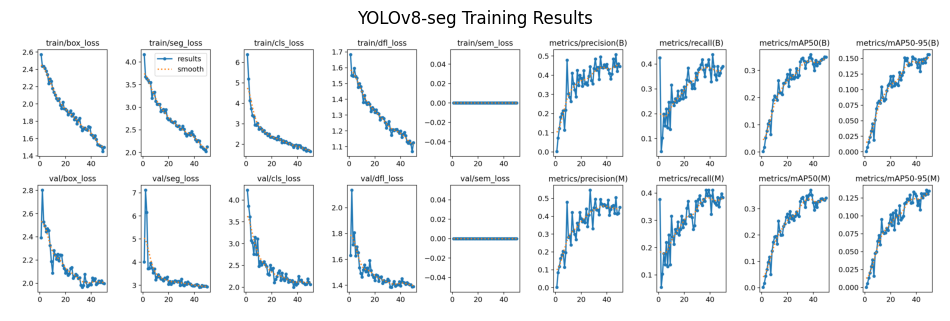

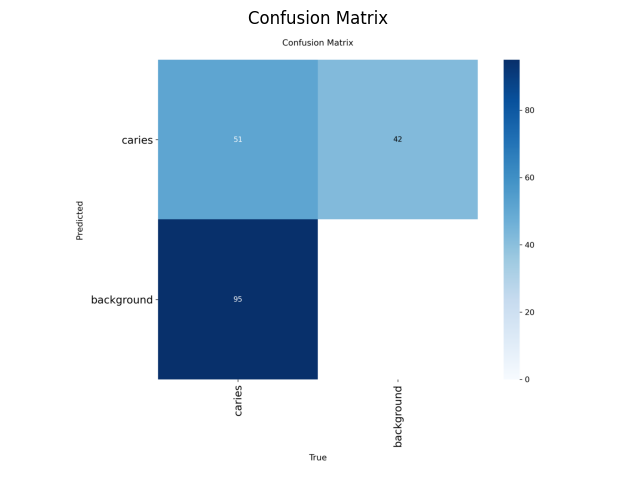

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_path = "/content/drive/MyDrive/YOLO8/yolov8n_seg/"

img = mpimg.imread(results_path + "results.png")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLOv8-seg_baseline Training Results")
plt.show()

cm = mpimg.imread(results_path + "confusion_matrix.png")
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

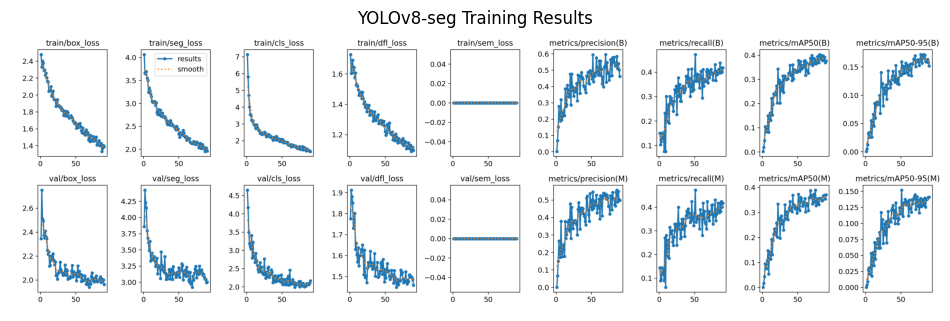

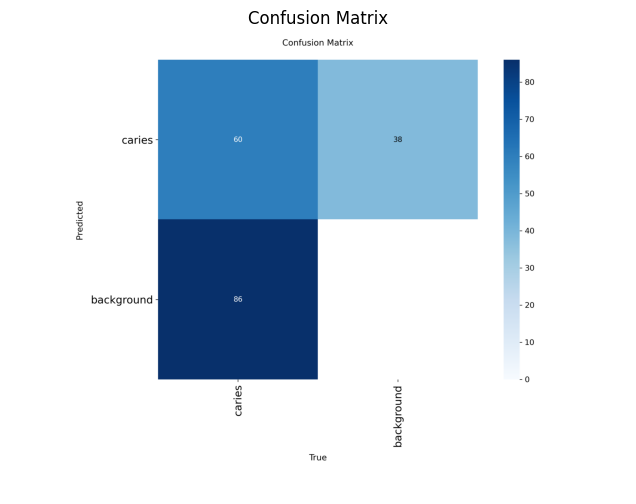

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_path = "/content/drive/MyDrive/YOLO8/yolov8n_seg_improved/"

img = mpimg.imread(results_path + "results.png")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLOv8-seg_improved Training Results")
plt.show()

cm = mpimg.imread(results_path + "confusion_matrix.png")
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

## Conclusion
The improved run perfomed better than the baseline across all metrics, confirming that the larger image size and additional training epochs were beneficial.Earlt stopping triggered at epochs 90 rather than completing the full 100 epochs, which shows it was working as intended to prevent the model from overfitting on the small dataset.

Having said that, the overall performance figures from both runs are modest, which is expected given the small size of the dataset.
Phase one was never intended to produce publication ready results as the goal was to develop and validate the pipeline before applying it to the CariXray in phase two.

These results, confirmed the segmentation pipeline is working and informed the configuration decisions applied in phase two.

The same configuration was applied to YOLO-26 seg in experiment three for direct comparison.